# A single CCM calculation

This notebook walks through Convergent Cross-Mapping end to end for **one**
`(E, τ, lag)` configuration of **one** dyad — the smallest unit of the whole
analysis, and the building block every later notebook aggregates across. Run this
same calculation for all 49 (E, τ) pairs at their optimal lag (the batches that
[Expand Master Parameter List](../Utilities/1_setup__expand_master_param_list.ipynb) and [Configure CCM Run Sets](../Utilities/2_setup__configure_CCM_run_sets.ipynb)
generate) and you get one fully calculated dyad — the unit that feeds the multi-dyad
result grids in [`Part 4`](../3_CCM_multi_dyad/_overview.md). This notebook exists to make that pipeline, described
in Methods (*Workflow*) and Supplement Text S1.2, concrete and inspectable: build
time-delay embeddings, sample a library, find nearest neighbors, predict, correlate,
and repeat across library sizes to build the convergence trajectory that underlies
every later ρ value and figure in the paper.


In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
from operator import index
from pathlib import Path
import os
import sys
import itertools


In [29]:
import numpy as np
import pandas as pd
pd.option_context('mode.use_inf_as_na', True)

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=UserWarning)#, module='seaborn')
warnings.filterwarnings("ignore", category=FutureWarning)#, module='seaborn')
warnings.simplefilter("ignore", category=FutureWarning)

from cedarkit.core.project_config import load_config
from cedarkit.utils.routing.paths import *
from cedarkit.utils.routing.file_name_parsers import *
from cedarkit.core.data_objects import *
from cedarkit.viz.panels import *
from cedarkit.core.data_var import *


In [14]:
stem = Path(*(p := Path.cwd().resolve()).parts[: p.parts.index("notebooks")])
proj_stem = stem / 'hol_temp_tsi_ccm'
print(proj_stem)

/Users/jlanders/PycharmProjects/hol_temp_tsi_ccm_pb/hol_temp_tsi_ccm


In [15]:
import inspect
def gen_save_path(fig_dir, stem=None):
    stem = stem if isinstance(stem, str) == True else inspect.currentframe().f_back.f_code.co_name
    date_id = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
    return fig_dir / f'{stem}_{date_id}.pdf'

`dyad_name` and `parameter_csv` pick which temperature–TSI pairing and which
pre-expanded `(E, τ, lag, ...)` parameter row to run — here, the ERB22–WU18 dyad at
lag = 2 decades, E = 6, τ = 1. `parameter_csv` comes out of
[Expand Master Parameter List](../Utilities/1_setup__expand_master_param_list.ipynb); this notebook just consumes one row of it
at a time rather than regenerating the sweep.


In [16]:
dyad_name= 'Erb22daGMST_Wu18TSI'#'GISP2Alley00TanomLinear' 'Erb22daGMSTLinear'
dyad_dir = proj_stem/f'{dyad_name}'#Path(os.getcwd()).resolve().parents[0]
parameter_csv = dyad_dir/'parameters/params_Wu18TSI_knn20lags_E6_tau1_Erb22daGMST_Wu18TSI.csv'


In [17]:
config = load_config(dyad_dir / 'proj_config.yaml')

calc_location =set_calc_path(None, dyad_dir, config, '')
calc_location.mkdir(parents=True, exist_ok=True)

output_location = set_output_path(None, calc_location, config)
output_location.mkdir(parents=True, exist_ok=True)

parameter_dir = dyad_dir / 'parameters'
tmp_dir = dyad_dir/'tmp'


In [20]:
parameter_df = pd.read_csv(parameter_csv)
pset_d = parameter_df[(parameter_df['lag']==2) & (parameter_df['E']==6) & (parameter_df['tau']==1)].iloc[0].to_dict()

start = pset_d.get("train_ind_i", 0)
pset_d["train_ind_i"] = 0 if pd.isna(start) else int(start)

if "train_ind_f" in pset_d:
    end = pset_d["train_ind_f"]
    pset_d["train_ind_f"] = None if pd.isna(end) else int(end)

In [57]:
ccm_obj = CCMConfig(pset_d, config, proj_dir = dyad_dir)


# Run CCM locally

This cell runs CCM for one (E, τ) configuration of one dyad (here Erb22-Wu18, E=6, τ=1, lag=2). The pipeline Methods and Supplement Text S1.2 spell out the concepts behind these steps, but the workflow is as follows below.

> Note: pyEDM runs both relationship directions, so one variable is passed as the column variable and the other is passed as the target variable despite the fact that both variables will play both roles. For clarity, in the explanation below `col_var` is the variable being considered in the "influenced" role and `target_var` is the variable being considered in the "influencer" role.

1. build time-delay embeddings for the `col_var` series
2. randomly sample a library of `col_var` embedding vectors
3. for each time `t`, find the `k` embedding vectors most similar to the embedding vector associated with `t` (the nearest neighbors), excluding a (E−1)×τ radius to avoid dependent samples
4. predict the `target_var` for each time by averaging `target_var` values at times associated with nominated neighbors
5. compute CCM skill ρ as the correlation between predicted and observed.

This is repeated for various library sizes ranging from small to large to test convergence.


In [80]:
cpu_count = 4
self_predict = False
start_ind = 0
time_offset = 0
overwrite = True

ccm_obj.cpus =cpu_count
ccm_obj.self_predict = self_predict
ccm_obj.min_window = None
ccm_obj.set_libsizes() # sets calculation to run over a range of library sizes, rather than limited to extreme ends of the spectrum.
ccm_out_df, df_path = ccm_obj.run_ccm(overwrite=overwrite, ind= start_ind+time_offset)


CCM run file handling decision - pset_exists: True, overwrite: False, run_continue: True


Checking existence of CCM output at /Users/jlanders/PycharmProjects/hol_temp_tsi_ccm_pb/hol_temp_tsi_ccm/Erb22daGMST_Wu18TSI/calc_local_tmp/calc_refactor/knn_20/tp_1/Erb22daGMST_Wu18TSI/E6_tau1/lag2/1786473082835_E6_tau1_lag2__neither0.csv: True
Checking existence of CCM output at /Users/jlanders/PycharmProjects/hol_temp_tsi_ccm_pb/hol_temp_tsi_ccm/Erb22daGMST_Wu18TSI/calc_local_tmp/calc_refactor/knn_20/tp_1/Erb22daGMST_Wu18TSI/E6_tau1/lag2/1786473082835_E6_tau1_lag2__neither0.csv: True
!	wrote to file:  /Users/jlanders/PycharmProjects/hol_temp_tsi_ccm_pb/hol_temp_tsi_ccm/Erb22daGMST_Wu18TSI/calc_local_tmp/calc_refactor/knn_20/tp_1/Erb22daGMST_Wu18TSI/E6_tau1/lag2/1786473082835_E6_tau1_lag2__neither0.csv


In [96]:
ccm_out_df = pd.read_csv(df_path)
out_col = OutputCollection(grp_specs= ccm_obj.rc, in_table=ccm_out_df, tmp_dir=tmp_dir)
out_col.aggregate_libsize()
agg = out_col.libsize_aggregated

The plot below is one panel's worth of Fig. S3: CCM skill (ρ) as a function of
library size, for this one (E, τ, lag) configuration. A configuration only counts as
evidence of causality if ρ improves with library size (Δρ = ρ_final − ρ_initial > 0)
*and* tends toward a stable value (Methods: *Workflow*) — convergence is the
signature that the relationship is well sampled, not just that more data happens to
correlate better. Run this for every (E, τ) in the sweep and every lag, and you get
the ρ values that populate the full-dyad result grids two sections from now.


In this classic CCM plot below, the CCM skill associated with the "TSI causes temp" relationship (red) increases with increasing library size, converging on a stable value. This is consistent with the notion that more information (a larger library size) will improve predictions until the system is well sampled by the available snippets. The final value reflects the actual information recovery by temperature of TSI. In contrast to the red line, the "temp causes TSI" relationship (blue) increases abruptly and then plateaus. This is an indication of a statistical relationship--the skill that would arise by chance.

['E', 'tau', 'Tp', 'lag', 'knn', 'surr_var', 'surr_num', 'x_id', 'x_age_model_ind', 'x_var', 'y_id', 'y_age_model_ind', 'y_var', 'LibSize', 'ind_i', 'relation', 'forcing', 'responding', 'Unnamed: 0', 'rho', 'MAE', 'RMSE']
['E', 'tau', 'Tp', 'lag', 'knn', 'surr_var', 'surr_num', 'x_id', 'x_age_model_ind', 'x_var', 'y_id', 'y_age_model_ind', 'y_var', 'LibSize', 'ind_i', 'relation_0', 'forcing', 'responding', 'Unnamed: 0', 'rho', 'MAE', 'RMSE', 'relation']


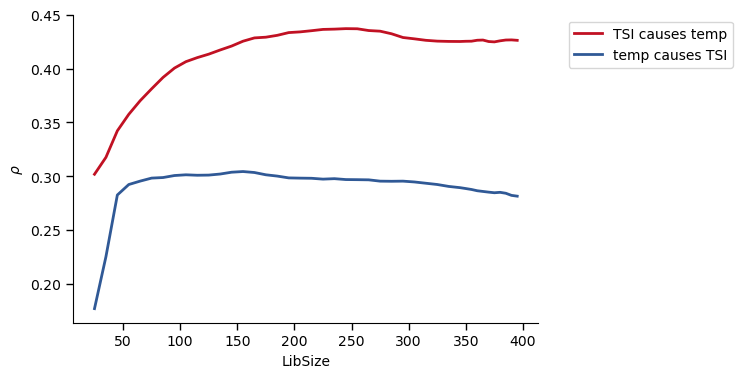

In [97]:
fig, ax = plt.subplots(figsize=(6,4))
lag_sub = LibSizeRhoPlot(lag=out_col.grp_config.lag, ax=ax, palette=config.pal.to_dict())
lag_sub.make_classic_plot(out_col, smoothed=True)
lag_sub.tidy_plot(legend=True)